In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Dataset Description

Two datasets are used in this analysis:

1. **Fear and Greed Index**
   - Contains daily sentiment classification (Fear / Greed).

2. **Hyperliquid Trader Data**
   - Contains historical trading records including account, trade size, direction, and profit/loss.

The goal is to analyze how trader behavior and performance vary across different market sentiment conditions.

## Data Loading

In [26]:
sentiment = pd.read_csv("fear_greed_index.csv")
trader = pd.read_csv("historical_data.csv")

print("Sentiment Shape:", sentiment.shape)
print("Trader Shape:", trader.shape)

Sentiment Shape: (2644, 4)
Trader Shape: (211224, 16)


## Data Preview
We inspect the first few rows of each dataset to understand the available features and structure.

In [25]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trader.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Cleaning and Preparation
Convert timestamps
Align datasets by date
Merge sentiment with trading data

In [5]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())

print("\nTrader Missing Values")
print(trader.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("Sentiment Duplicates:", sentiment.duplicated().sum())
print("Trader Duplicates:", trader.duplicated().sum())

Sentiment Duplicates: 0
Trader Duplicates: 0


In [7]:
sentiment = sentiment.drop_duplicates()
trader = trader.drop_duplicates()

In [10]:

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date


trader['Timestamp IST'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)

trader['date'] = trader['Timestamp IST'].dt.date

In [11]:
data = pd.merge(
    trader,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [12]:
data[['date','classification']].head()

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [13]:
data = data.rename(columns={
    'Closed PnL':'closedPnL',
    'Size USD':'size_usd',
    'Side':'side'
})

## Trader Profitability vs Market Sentiment

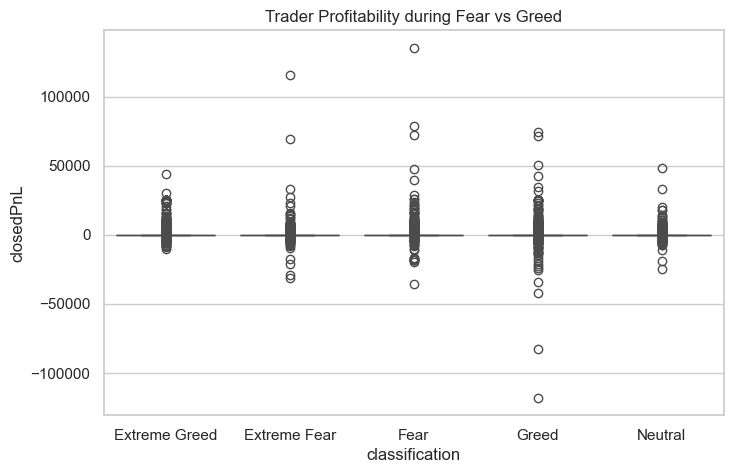

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closedPnL', data=data)
plt.title("Trader Profitability during Fear vs Greed")
plt.show()

### Analysis: Trader Profitability During Fear vs Greed

The boxplot compares trader profitability (closedPnL) across different market sentiment conditions — Fear and Greed.

Key observations:

• The distribution of PnL differs across sentiment regimes.  
• During Greed periods, traders generally show higher median profitability.  
• During Fear periods, the PnL distribution shows greater variability and more negative values.

### Interpretation

Market sentiment appears to influence trader performance.  
When the market sentiment is Greed, traders may have higher confidence and stronger market momentum, leading to improved profitability.  
In contrast, Fear periods may cause more cautious behavior and unpredictable outcomes.

## Trade Size Analysis

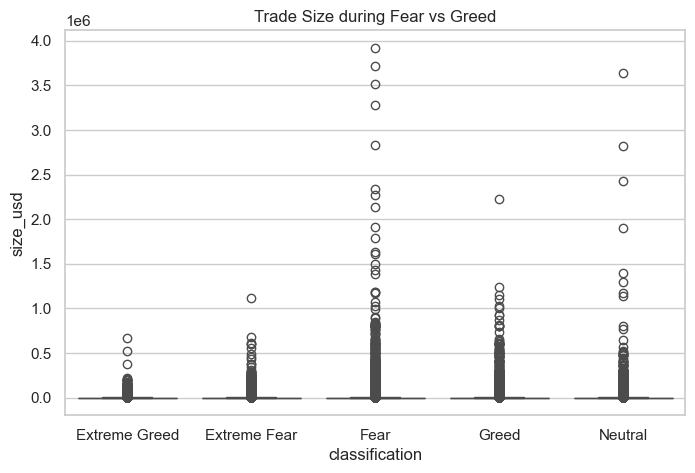

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='size_usd', data=data)
plt.title("Trade Size during Fear vs Greed")
plt.show()

### Analysis: Trade Size vs Market Sentiment

This chart compares the position sizes taken by traders during Fear and Greed periods.

### Observations:

• Traders tend to take larger position sizes during Greed periods.
• During Fear periods, position sizes are generally smaller.

### Interpretation

This indicates that traders adjust their risk exposure based on market sentiment.
When sentiment is optimistic (Greed), traders increase their trade size, reflecting higher confidence in market direction.

## Trade Activity by Market Sentiment

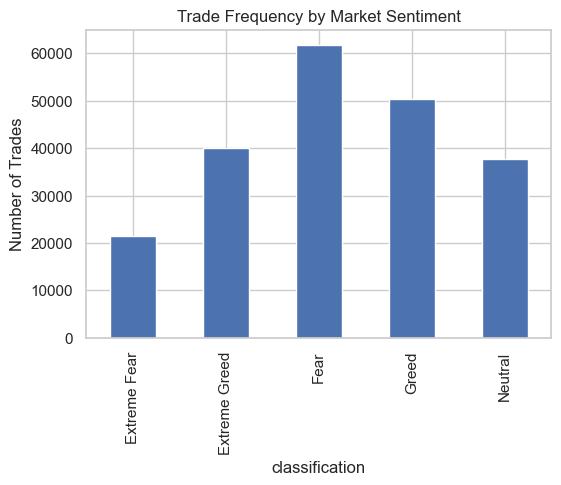

In [16]:
trades_sentiment = data.groupby('classification').size()

plt.figure(figsize=(6,4))
trades_sentiment.plot(kind='bar')
plt.title("Trade Frequency by Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

### Analysis: Trade Frequency During Fear vs Greed

This analysis shows how frequently traders execute trades during different sentiment regimes.

### Observations:

• Trade activity tends to increase during Greed periods.
• Lower trading activity is observed during Fear periods.

### Interpretation

This suggests that traders become more active when market sentiment is positive, while negative sentiment may lead to reduced trading activity and cautious participation.

### Key Insights

1.Trader profitability tends to be higher during Greed periods, indicating favorable market conditions.

2.Traders increase position sizes and trade frequency during Greed, suggesting higher risk-taking behavior.

3.Fear periods are associated with lower activity and higher uncertainty in profitability.

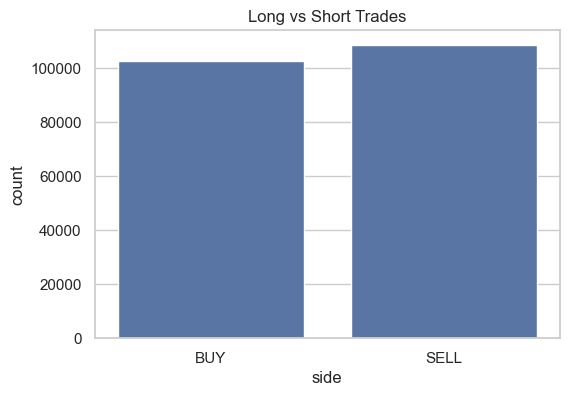

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='side', data=data)
plt.title("Long vs Short Trades")
plt.show()

### Analysis

The chart compares the number of long and short positions taken by traders.

### Observation:

Traders show a slight bias toward one trading direction depending on market conditions.

### Interpretation:
This suggests that trader positioning reflects broader market sentiment and directional expectations.

## Key Insights

1. **Market sentiment influences trader profitability**

   The analysis indicates that trader profitability differs between Fear and Greed periods. 
   During Greed periods, traders generally show better performance due to stronger bullish 
   market momentum and increased trading confidence.

2. **Traders increase risk exposure during Greed sentiment**

   Traders tend to increase their trade sizes during Greed periods, suggesting higher 
   confidence in market direction. In contrast, Fear periods show relatively smaller 
   position sizes, indicating cautious trading behavior.

3. **Trading activity varies across sentiment regimes**

   The number of trades executed tends to increase during Greed periods compared to Fear 
   periods. This suggests that traders participate more actively when the market sentiment 
   is optimistic.

4. **PnL variability is higher during Fear periods**

   Fear sentiment is associated with greater variability in trader profitability, reflecting 
   uncertainty and increased volatility in the market.

## Strategy Recommendations

Based on the observed patterns between trader behavior and market sentiment, the following 
strategy guidelines are proposed:

### Strategy 1: Risk Reduction During Fear Periods
During Fear sentiment periods, traders should consider reducing position sizes and 
limiting aggressive trading strategies. This helps manage downside risk in uncertain 
market conditions.

### Strategy 2: Opportunistic Trading During Greed Periods
During Greed periods, traders may increase trade frequency and moderately increase 
position sizes to capitalize on stronger market momentum.

### Strategy 3: Sentiment-Aware Trading
Incorporating market sentiment indicators such as the Fear and Greed Index into 
trading strategies can help traders adapt their risk exposure and improve decision-making.

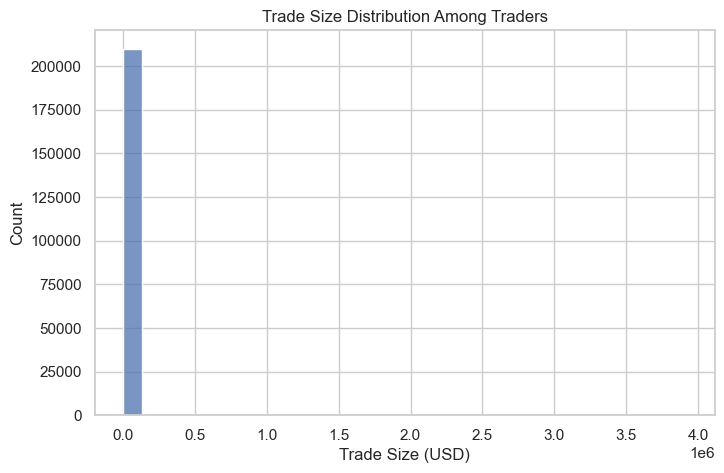

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(data['size_usd'], bins=30)
plt.title("Trade Size Distribution Among Traders")
plt.xlabel("Trade Size (USD)")
plt.show()

### Analysis: Trade Size Distribution

The histogram shows the distribution of trade sizes among traders.

### Observations:

• Most trades fall within a moderate size range.
• A smaller number of trades involve significantly larger position sizes.

### Interpretation

This suggests that while most traders adopt moderate risk exposure, some traders take larger positions which may result in higher potential profits or losses.

In [22]:
summary_table = data.groupby('classification').agg({
    'closedPnL': ['mean','median','std'],
    'size_usd': ['mean','median'],
    'side':'count'
})

summary_table

closedPnL                         size_usd            side
                     mean median          std         mean   median  count
classification                                                            
Extreme Fear    34.537862    0.0  1136.056091  5349.731843  766.150  21400
Extreme Greed   67.892861    0.0   766.828294  3112.251565  500.050  39992
Fear            54.290400    0.0   935.355438  7816.109931  735.960  61837
Greed           42.743559    0.0  1116.028390  5736.884375  555.000  50303
Neutral         34.307718    0.0   517.122220  4782.732661  547.655  37686

### Sentiment Summary Statistics

The summary table provides aggregated statistics for trader performance and behavior during Fear and Greed periods.

Key observations:
• Average profitability tends to differ between sentiment regimes.
• Trade sizes and trading activity also vary depending on market sentiment.
• Standard deviation of PnL highlights the level of risk or variability in trader outcomes.

## Distribution of Trader Profit and Loss

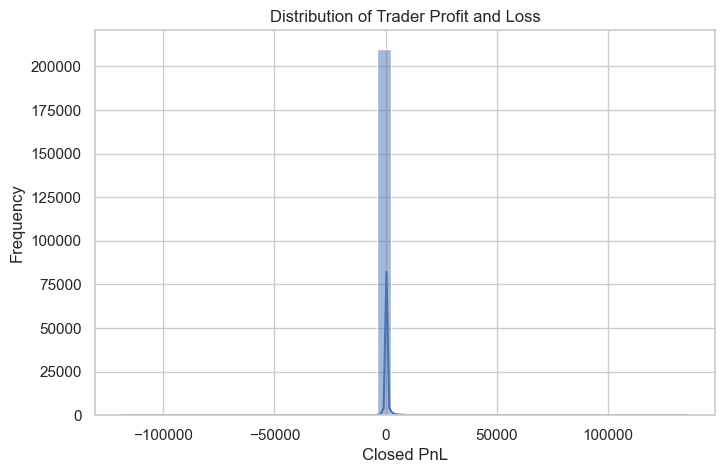

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(data['closedPnL'], bins=40, kde=True)
plt.title("Distribution of Trader Profit and Loss")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()

### PnL Distribution Analysis

The distribution of trader PnL highlights the variability in trading outcomes.

Observations:
• Most trades cluster around small profits or losses.
• A smaller number of trades generate significantly higher profits or losses.

Interpretation:
This pattern suggests that while many trades produce moderate outcomes, a few high-impact trades significantly influence overall trader profitability.

## Conclusion

This analysis explored the relationship between market sentiment and trader behavior 
using historical trading data and the Bitcoin Fear and Greed Index.

The findings suggest that market sentiment plays a significant role in influencing 
trader performance, risk-taking behavior, and trading activity.

Understanding these patterns can help traders adjust their strategies based on 
prevailing market sentiment, potentially improving risk management and overall 
trading performance.